## Multiple linear Regression


In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np
%matplotlib inline


In [2]:
df_index=pd.read_csv("economic_index.csv")

In [3]:
df_index

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256
5,5,2017,7,2.50,5.6,1254
6,6,2017,6,2.50,5.5,1234
7,7,2017,5,2.25,5.5,1195
8,8,2017,4,2.25,5.5,1159
9,9,2017,3,2.25,5.6,1167


In [4]:
## drop unnecessary columns 
df_index.drop(columns=["Unnamed: 0","year" , "month"] , axis=1 , inplace=True)

In [5]:
df_index

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [6]:
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

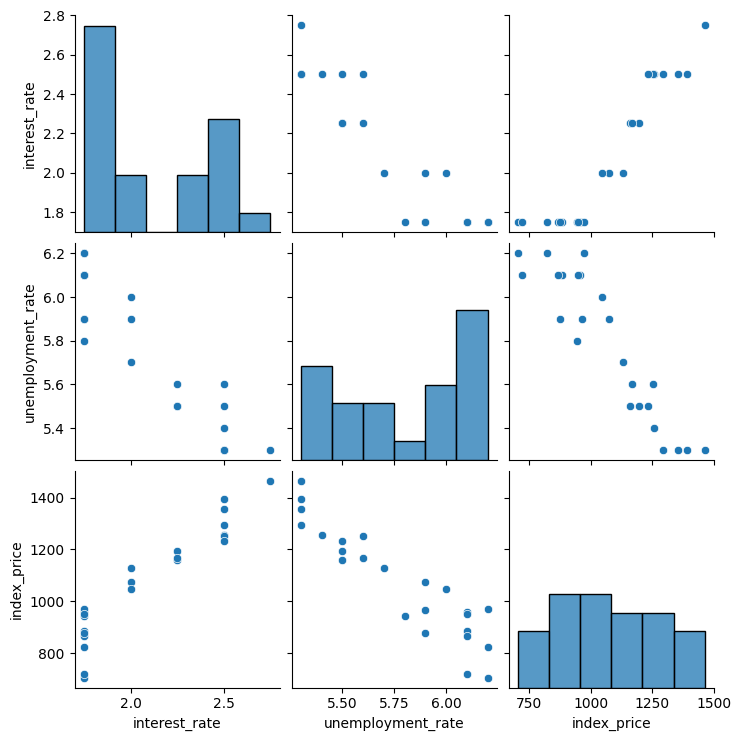

In [7]:
import seaborn as sns 
sns.pairplot(df_index)

In [8]:
df = df_index
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'UNEMPLOYMENT RATE')

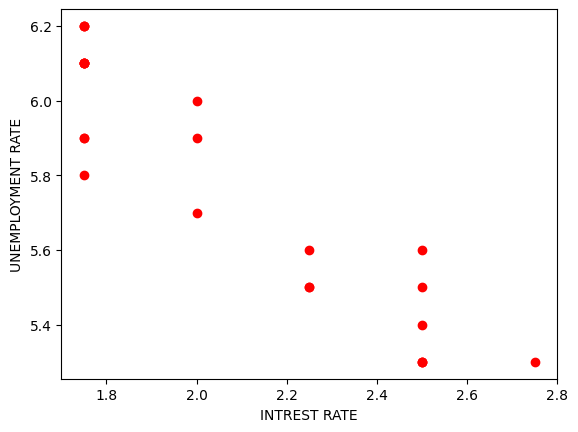

In [9]:
## visualizing more closely 

plt.scatter(df['interest_rate'] , df['unemployment_rate'] , color='r')
plt.xlabel("INTREST RATE")
plt.ylabel("UNEMPLOYMENT RATE")

In [10]:
## independent and dependent features  
x = df.iloc[ :  , : -1]

y=df.iloc[ : ,-1]

In [11]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [12]:
## train test split 
from sklearn.model_selection  import train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.25 , random_state=42)

In [14]:
df

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

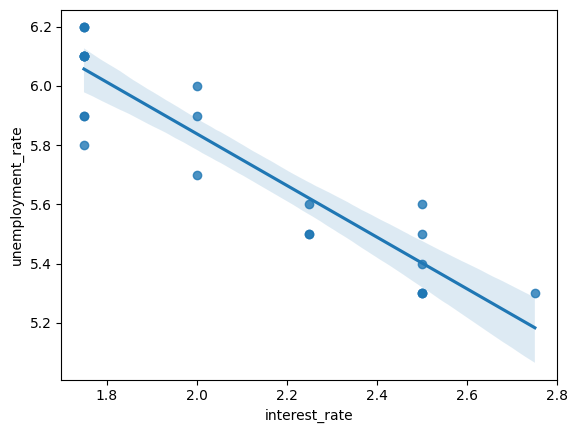

In [18]:
import seaborn as sns 

sns.regplot(x=df['interest_rate'], y=df['unemployment_rate'])


In [22]:
from sklearn.preprocessing import StandardScaler 
scalar = StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.fit_transform(x_test)

In [23]:
x_test

array([[ 0.36115756, -0.82078268],
       [-1.08347268,  1.33377186],
       [ 1.8057878 , -1.43636969],
       [-1.08347268,  1.02597835],
       [-0.36115756,  0.41039134],
       [ 0.36115756, -0.51298918]])

In [26]:
from sklearn.linear_model import LinearRegression 
regression = LinearRegression()


In [27]:
regression.fit(x_train , y_train )

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
regression.coef_

array([  88.27275507, -116.25716066])

In [28]:
from sklearn.model_selection import cross_val_score 
validation_score = cross_val_score(regression , x_train , y_train , scoring='neg_mean_squared_error' ,cv=3)


## cv = 5 if i have 1000 records into train 900 and test 100 split 
## to make my model better i can split train into train + validation 

In [29]:
np.mean(validation_score)

np.float64(-5914.828180162386)

In [30]:
## prediction 
y_pred=regression.predict(x_test)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse=mean_squared_error(y_test , y_pred)
mae=mean_absolute_error(y_test , y_pred)
rmse=np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


In [32]:
from sklearn.metrics import r2_score
score = r2_score(y_test  , y_pred)
print (score)

0.7591371539010257


## ASSUMPTIONS

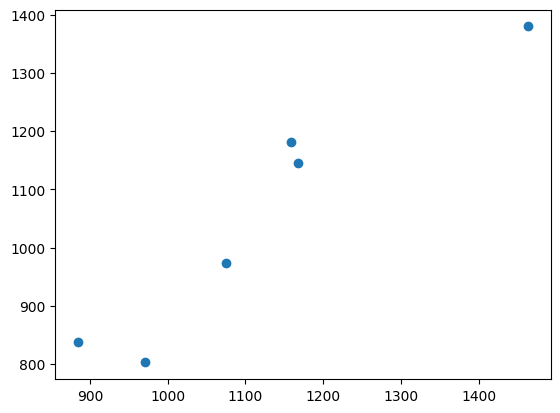

In [33]:
plt.scatter(y_test ,y_pred)

In [34]:
residuals=y_test-y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


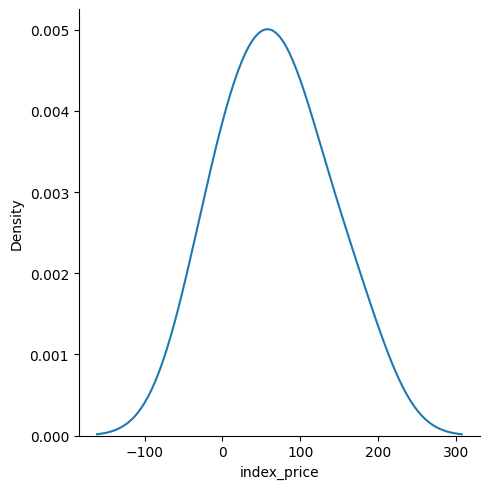

In [35]:
## ## plot this residuals 
sns.displot(residuals , kind='kde')

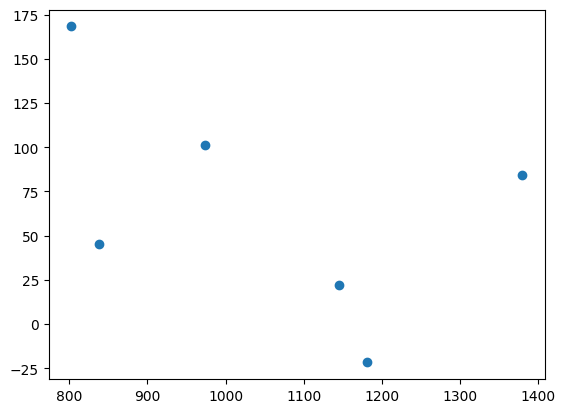

In [36]:
### scatter plot wrto predictions and residuals 

plt.scatter(y_pred , residuals)

In [37]:
## OLS LInear regression 

import statsmodels.api as sm 
model=sm.OLS(y_train , x_train).fit()

In [38]:
model.summary()

c:\Users\saura\OneDrive\Desktop\VS CODE FILES\python ml\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Wed, 12 Aug 2026   Prob (F-statistic):                       0.754
Time:                        15:03:55   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1            88.2728    658.295      0.134      0.895   -1307.250    1483.796
x2          -116.2572    658.295     -0.177      0.862   -1511.780    1279.266
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   0.007
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""